In [5]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 116, done.
remote: Counting objects: 100% (116/116), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 116 (delta 51), reused 92 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (116/116), 795.00 KiB | 23.38 MiB/s, done.
Resolving deltas: 100% (51/51), done.
/content/miniml/miniml/miniml


In [6]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.datasets import load_iris, load_wine, make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from naive_bayes.gaussian import NBGaussianClassifier

In [7]:
np.random.seed(42)
plt.rcParams['figure.figsize'] = (10, 6)

In [8]:
X_iris, y_iris = load_iris(return_X_y=True)
Xi_train, Xi_test, yi_train, yi_test = train_test_split(X_iris, y_iris, test_size=0.3, random_state=42)

print(f"Iris: {X_iris.shape[0]} объектов, {X_iris.shape[1]} признака, {len(np.unique(y_iris))} класса")

Iris: 150 объектов, 4 признака, 3 класса


In [9]:
X_synth, y_synth = make_classification(
    n_samples=400, n_features=2, n_informative=2, n_redundant=0,
    n_classes=3, n_clusters_per_class=1, class_sep=1.5, random_state=42
)
Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_synth, y_synth, test_size=0.3, random_state=42)

In [10]:
my_model = NBGaussianClassifier()
my_model.fit(Xi_train, yi_train)
my_pred = my_model.predict(Xi_test)

sk_model = GaussianNB()
sk_model.fit(Xi_train, yi_train)
sk_pred = sk_model.predict(Xi_test)

my_acc = accuracy_score(yi_test, my_pred)
sk_acc = accuracy_score(yi_test, sk_pred)
match_rate = np.mean(my_pred == sk_pred)

print(f"Iris — своя accuracy:     {my_acc:.4f}")
print(f"Iris — sklearn accuracy:  {sk_acc:.4f}")
print(f"Совпадение предсказаний с sklearn поточечно: {match_rate:.4f} (ожидается 1.0)")

Iris — своя accuracy:     0.9778
Iris — sklearn accuracy:  0.9778
Совпадение предсказаний с sklearn поточечно: 1.0000 (ожидается 1.0)


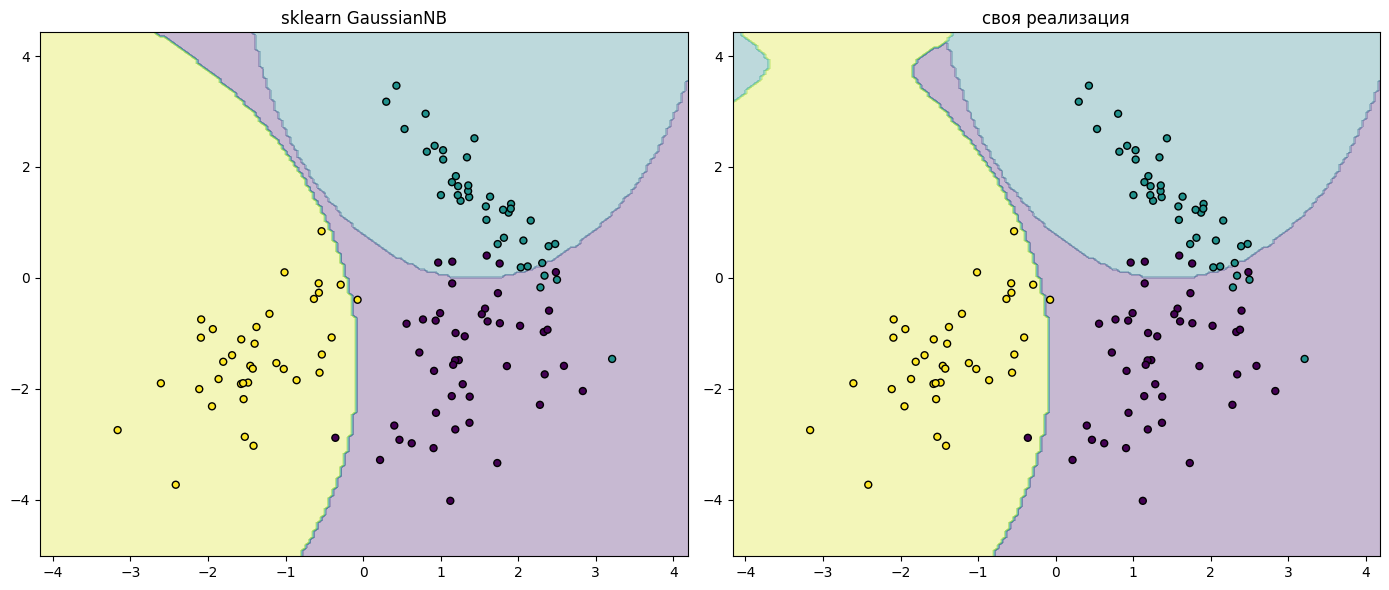

In [17]:
def plot_decision_boundary(model, X, y, ax, title, is_sklearn=False):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    grid = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolors='k', s=25)
    ax.set_title(title)


my_synth_model = NBGaussianClassifier()
my_synth_model.fit(Xs_train, ys_train)

sk_synth_model = GaussianNB()
sk_synth_model.fit(Xs_train, ys_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_decision_boundary(sk_synth_model, Xs_test, ys_test, axes[0], 'sklearn GaussianNB')
plot_decision_boundary(my_synth_model, Xs_test, ys_test, axes[1], 'своя реализация')
plt.tight_layout()
plt.savefig('nb_decision_boundaries.png', dpi=100)
plt.show()

In [12]:
my_proba = my_model.predict_proba(Xi_test)  # shape (n_classes, n_samples) — транспонируем для сравнения
my_proba_T = my_proba.T  # -> (n_samples, n_classes)

sk_proba = sk_model.predict_proba(Xi_test)  # (n_samples, n_classes)

max_diff_proba = np.max(np.abs(my_proba_T - sk_proba))
print(f"predict_proba: максимальное расхождение с sklearn = {max_diff_proba:.2e}")
print("(должно быть маленьким, ~1e-6 или меньше — формула log-sum-exp корректна)")

predict_proba: максимальное расхождение с sklearn = 8.98e-09
(должно быть маленьким, ~1e-6 или меньше — формула log-sum-exp корректна)


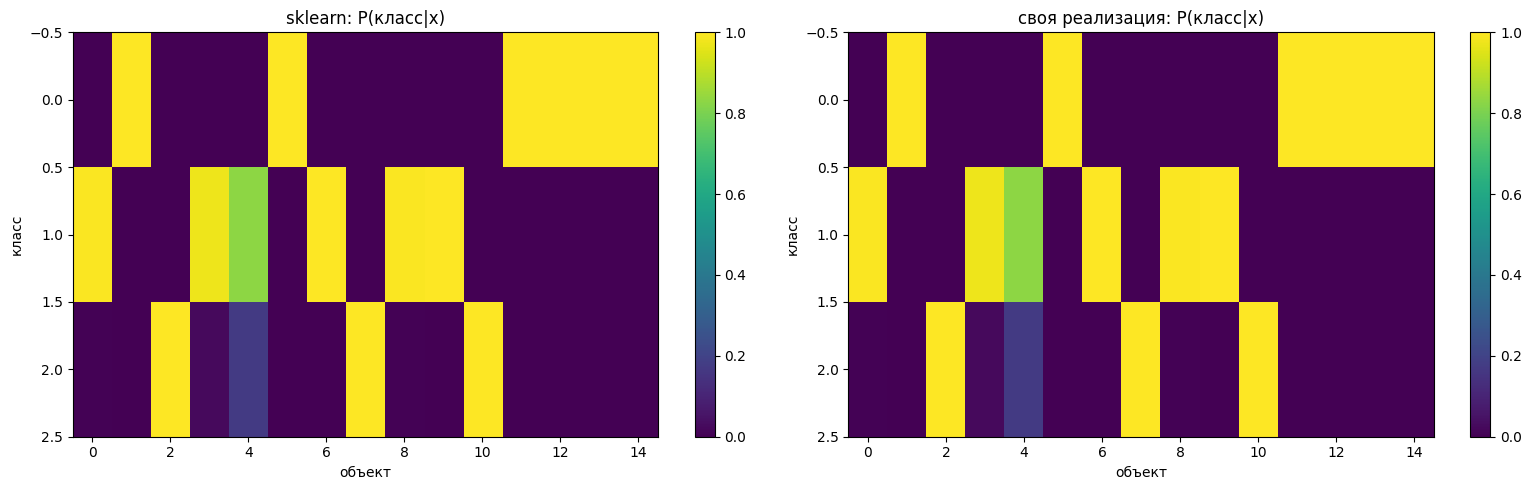

In [13]:
n_show = 15
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im0 = axes[0].imshow(sk_proba[:n_show].T, aspect='auto', cmap='viridis')
axes[0].set_title('sklearn: P(класс|x)')
axes[0].set_xlabel('объект')
axes[0].set_ylabel('класс')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(my_proba[:, :n_show], aspect='auto', cmap='viridis')
axes[1].set_title('своя реализация: P(класс|x)')
axes[1].set_xlabel('объект')
axes[1].set_ylabel('класс')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.savefig('nb_probabilities_heatmap.png', dpi=100)
plt.show()

In [14]:
X_wine, y_wine = load_wine(return_X_y=True)
Xw_train, Xw_test, yw_train, yw_test = train_test_split(X_wine, y_wine, test_size=0.3, random_state=42)

my_wine = NBGaussianClassifier()
my_wine.fit(Xw_train, yw_train)
my_wine_pred = my_wine.predict(Xw_test)

sk_wine = GaussianNB()
sk_wine.fit(Xw_train, yw_train)
sk_wine_pred = sk_wine.predict(Xw_test)

print(f"Wine ({X_wine.shape[1]} признаков) — своя accuracy:    {accuracy_score(yw_test, my_wine_pred):.4f}")
print(f"Wine ({X_wine.shape[1]} признаков) — sklearn accuracy: {accuracy_score(yw_test, sk_wine_pred):.4f}")

Wine (13 признаков) — своя accuracy:    1.0000
Wine (13 признаков) — sklearn accuracy: 1.0000


In [15]:
pred_log = my_model.predict(Xi_test, use_logarithm=True)
pred_nolog = my_model.predict(Xi_test, use_logarithm=False)

print(f"predict(): лог-режим и обычный режим дают одинаковые классы: {np.array_equal(pred_log, pred_nolog)}")

# демонстрация why-log-matters: сколько признаков нужно, чтобы обычный режим начал давать nan/inf
for n_feat in [10, 50, 100, 200, 300]:
    X_demo = np.random.randn(100, n_feat)
    y_demo = np.random.randint(0, 2, 100)
    m = NBGaussianClassifier()
    m.fit(X_demo, y_demo)
    m.predict(X_demo, use_logarithm=False)
    has_issue = np.isnan(m.predicted).any() or np.isinf(m.predicted).any() or (m.predicted == 0).all()
    print(f"  {n_feat:4} признаков, без логарифма: проблема с числами = {has_issue}")

predict(): лог-режим и обычный режим дают одинаковые классы: True
    10 признаков, без логарифма: проблема с числами = False
    50 признаков, без логарифма: проблема с числами = False
   100 признаков, без логарифма: проблема с числами = False
   200 признаков, без логарифма: проблема с числами = False
   300 признаков, без логарифма: проблема с числами = False


In [16]:
print(f"Iris accuracy:  своя={my_acc:.4f} / sklearn={sk_acc:.4f} / совпадение поточечно={match_rate:.4f}")
print(f"Wine accuracy:  своя={accuracy_score(yw_test, my_wine_pred):.4f} / sklearn={accuracy_score(yw_test, sk_wine_pred):.4f}")
print(f"predict_proba max_diff vs sklearn: {max_diff_proba:.2e}")

Iris accuracy:  своя=0.9778 / sklearn=0.9778 / совпадение поточечно=1.0000
Wine accuracy:  своя=1.0000 / sklearn=1.0000
predict_proba max_diff vs sklearn: 8.98e-09
